# SMT figures

All plots driven by the **already-trained** model checkpoints (no training in this notebook). One plot per cell.

**Before running:** produce the two checkpoints once from the CLI —
```
python mlp_paper.py --model-out results/mlp_paper_model.pt
python mlp.py       --model-out results/mlp_abstention_model.pt
```
Then run the cells top to bottom: the helpers cell, the load cell, then any figure.

In [53]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt

# render figures inline in the notebook (overrides a stale Agg backend so
# plt.show() actually displays instead of warning "FigureCanvasAgg ... cannot be shown")
%matplotlib inline

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from generator import defect_names, load_spec, param_ids
from mlp_common import _encode, evaluate, load_model

# class colors (by index and by name): no_defect grey, open blue, bridge red
DEFECT_COLORS = {0: "#8a8d91", 1: "#2f6db5", 2: "#c1432e"}
DEFECT_HEX = {"no_defect": "#8a8d91", "open_circuit": "#2f6db5",
              "solder_bridging": "#c1432e"}
SHORT = {"no_defect": "none", "open_circuit": "open", "solder_bridging": "bridge"}


def _pack(model, enc, df, spec, split="test"):
    """Algorithm — Predict on one split and bundle what the plots need.

    Input: a trained model, its enc bundle, df, spec, split name.
    Return: predictions, true labels, the known posterior, risk, and (for the
    abstention model only) the abstain prob r.
    """

    # pull RAW features for the split and standardize with stored train stats
    ids, names = param_ids(spec), defect_names(spec)
    te = np.where(df["split"].to_numpy() == split)[0]
    Xraw = df.iloc[te][ids].to_numpy(np.float32)
    X = ((Xraw - enc["mu"]) / enc["sd"]).astype(np.float32)

    # per-head probabilities + argmax (the evidence payload)
    pred = model.predict(torch.from_numpy(X))
    y = enc["y_def"][te]
    post = df.iloc[te][[f"p_{n}" for n in names]].to_numpy()
    pack = {"te": te, "y": y, "post": post, "names": names,
            "d_pred": pred["defect_argmax"].cpu().numpy(),
            "defect_prob": pred["defect_prob"].cpu().numpy(),
            "risk_prob": pred["risk_prob"].cpu().numpy(),
            "y_risk": enc["y_risk"][te]}

    # abstain prob exists only for the abstention model
    if "abstain_prob" in pred:
        pack["r"] = pred["abstain_prob"].cpu().numpy()
    return pack


def _sel_curve(correct, conf):
    """Selective accuracy vs coverage: accept highest-confidence boards first."""

    # sort by confidence descending, then take a running accuracy of the top-k
    order = np.argsort(-conf)
    sel = correct[order].cumsum() / np.arange(1, len(correct) + 1)
    cov = np.arange(1, len(correct) + 1) / len(correct)
    return cov, sel


def overlap(a, b, bins=60):
    """Histogram overlap coefficient of two samples (1 = identical, 0 = disjoint)."""

    # share a common range, density-normalize each, then sum the per-bin minimum
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    edges = np.linspace(lo, hi, bins + 1)
    ha, _ = np.histogram(a, edges, density=True)
    hb, _ = np.histogram(b, edges, density=True)
    return float(np.minimum(ha, hb).sum() * (edges[1] - edges[0]))


def param_causal_note(spec):
    """Map each parameter to a short note of its causal role (for hist labels)."""

    # collect the (direction -> defect) edges that touch each parameter
    notes = {p["id"]: [] for p in spec["parameters"]}
    short = {"solder_bridging": "bridging", "open_circuit": "open"}
    for e in spec["causal_edges"]:
        notes[e["parameter"]].append(f"{e['direction']}->{short.get(e['defect'], e['defect'])}")

    # parameters with no edge are nuisance variables
    return {p: (", ".join(sorted(set(v))) if v else "nuisance (no causal edge)")
            for p, v in notes.items()}

## Setup — load the two trained checkpoints

In [54]:
# Load spec, data, and the TWO already-trained checkpoints. No training happens in
# this notebook -- produce the checkpoints once from the CLI first:
#   python mlp_paper.py --model-out results/mlp_paper_model.pt
#   python mlp.py       --model-out results/mlp_abstention_model.pt
spec = load_spec("domain/smt_paper.yaml")
df = pd.read_csv("data/smt_synthetic.csv")
figs = Path("figs")
figs.mkdir(exist_ok=True)


def load_pack(path):
    """Algorithm — Load a trained checkpoint and build everything the plots need.

    Input: a checkpoint path written by run_cli().
    Return: (model, enc bundle, test-split metrics dict, test-split predict pack).
    """

    # rebuild the model + its train-time standardization stats, no retraining
    model, ckpt = load_model(path)
    enc = _encode(df, spec)                          # labels/targets straight from the data
    enc["mu"], enc["sd"] = ckpt["standardize"]["mu"], ckpt["standardize"]["sd"]
    enc["val_loss_history"] = ckpt.get("val_loss_history", [])
    enc["best_epoch"] = ckpt.get("best_epoch", 0)
    metrics = evaluate(model, enc, df, spec, model_version=ckpt["model_version"])
    return model, enc, metrics, _pack(model, enc, df, spec)


model_mh, enc_mh, m_mh, mh = load_pack("results/mlp_paper_model.pt")        # CE baseline
model_ab, enc_ab, m_ab, ab = load_pack("results/mlp_abstention_model.pt")   # gambler loss
bayes = m_mh["bayes_optimal_accuracy"]
print("loaded", m_mh["model_version"], "and", m_ab["model_version"])
print(f"defect acc:  multihead {m_mh['defect_head']['accuracy']:.4f}   "
      f"abstention {m_ab['defect_head']['accuracy']:.4f}   bayes {bayes:.4f}")

loaded mlp-paper-v0.1 and mlp-v0.1
defect acc:  multihead 0.9510   abstention 0.9517   bayes 0.9534


## Model figures

Every figure below is computed from the two loaded models (`mh` = multihead/CE, `ab` = abstention/gambler) on the test split.

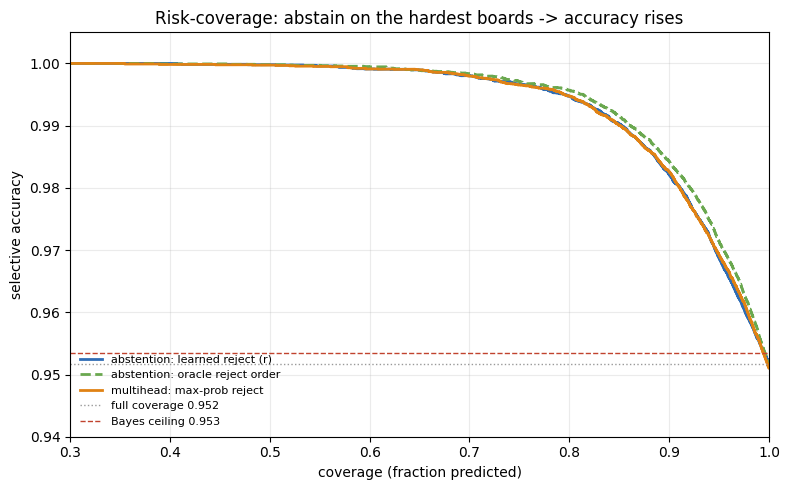

In [55]:
# Risk-coverage: selective accuracy vs coverage -- learned reject vs the oracle order.
fig, ax = plt.subplots(figsize=(8, 5))

# abstention model, rejecting by its LEARNED abstain prob (low r = keep)
cor_ab = (ab["d_pred"] == ab["y"]).astype(float)
cov, sel = _sel_curve(cor_ab, -ab["r"])
ax.plot(cov, sel, color="#2f6db5", lw=2, label="abstention: learned reject (r)")

# same predictions, but rejecting by the KNOWN posterior confidence (oracle order)
cov_o, sel_o = _sel_curve(cor_ab, ab["post"].max(1))
ax.plot(cov_o, sel_o, color="#6aa84f", lw=2, ls="--", label="abstention: oracle reject order")

# multihead model, rejecting by its own max class prob (no abstain head)
cor_mh = (mh["d_pred"] == mh["y"]).astype(float)
cov_m, sel_m = _sel_curve(cor_mh, mh["defect_prob"].max(1))
ax.plot(cov_m, sel_m, color="#e08214", lw=2, label="multihead: max-prob reject")

# full-coverage accuracy and the Bayes ceiling for reference
ax.axhline(cor_ab.mean(), color="#999", ls=":", lw=1, label=f"full coverage {cor_ab.mean():.3f}")
ax.axhline(bayes, color="#c1432e", ls="--", lw=1, label=f"Bayes ceiling {bayes:.3f}")
ax.set_xlabel("coverage (fraction predicted)")
ax.set_ylabel("selective accuracy")
ax.set_xlim(0.3, 1.0)
ax.set_ylim(0.94, 1.005)
ax.set_title("Risk-coverage: abstain on the hardest boards -> accuracy rises")
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(figs / "risk_coverage.png", dpi=140)
plt.show()

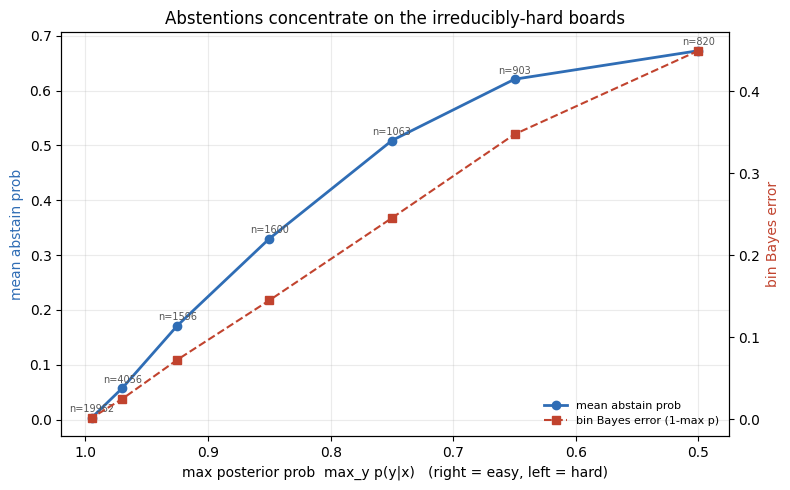

In [56]:
# Abstentions concentrate on the irreducibly-hard boards (by known posterior difficulty).
maxp = ab["post"].max(1)
r = ab["r"]
edges = np.array([0.40, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99, 1.0001])
idx = np.digitize(maxp, edges) - 1
centers, mean_r, bayes_err, counts = [], [], [], []
for b in range(len(edges) - 1):
    m = idx == b
    if not m.any():
        continue
    centers.append((edges[b] + min(edges[b + 1], 1.0)) / 2)
    mean_r.append(r[m].mean())
    bayes_err.append((1 - maxp[m]).mean())   # irreducible error of the bin
    counts.append(int(m.sum()))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, mean_r, "o-", color="#2f6db5", lw=2, label="mean abstain prob")
for c, v, n in zip(centers, mean_r, counts):
    ax.text(c, v + 0.01, f"n={n}", ha="center", fontsize=7, color="#555")
ax2 = ax.twinx()
ax2.plot(centers, bayes_err, "s--", color="#c1432e", lw=1.5, label="bin Bayes error (1-max p)")
ax.set_xlabel("max posterior prob  max_y p(y|x)   (right = easy, left = hard)")
ax.set_ylabel("mean abstain prob", color="#2f6db5")
ax2.set_ylabel("bin Bayes error", color="#c1432e")
ax.set_title("Abstentions concentrate on the irreducibly-hard boards")
ax.invert_xaxis()                                   # hardest on the left
ax.grid(alpha=0.25)
# one combined legend from both y-axes, tucked into the empty lower-right
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(figs / "abstention_vs_difficulty.png", dpi=140)
plt.show()

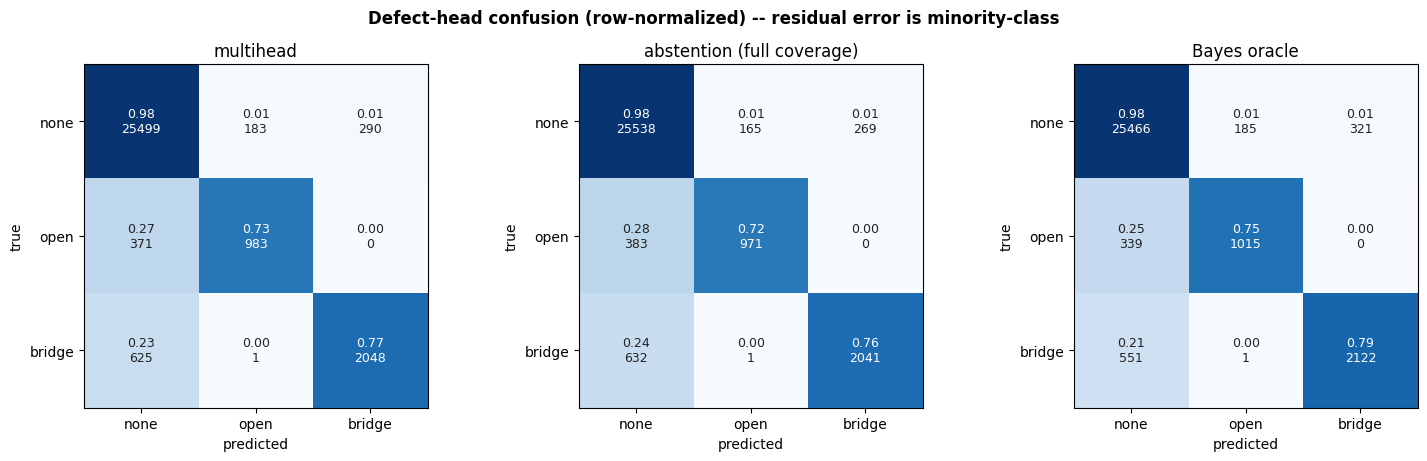

In [57]:
# Row-normalized defect confusion: multihead / abstention / Bayes oracle.
short_names = [SHORT[n] for n in mh["names"]]
panels = [("multihead", mh["d_pred"], mh["y"]),
          ("abstention (full coverage)", ab["d_pred"], ab["y"]),
          ("Bayes oracle", mh["post"].argmax(1), mh["y"])]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, pred, yt) in zip(axes, panels):
    cm = confusion_matrix(yt, pred, labels=[0, 1, 2]).astype(float)
    cmn = cm / cm.sum(1, keepdims=True)             # row-normalize (recall)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cmn[i, j]:.2f}\n{int(cm[i, j])}", ha="center", va="center",
                    fontsize=9, color="white" if cmn[i, j] > 0.5 else "#222")
    ax.set_xticks(range(3)); ax.set_xticklabels(short_names)
    ax.set_yticks(range(3)); ax.set_yticklabels(short_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
fig.suptitle("Defect-head confusion (row-normalized) -- residual error is minority-class",
             fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "confusion_matrices.png", dpi=140)
plt.show()

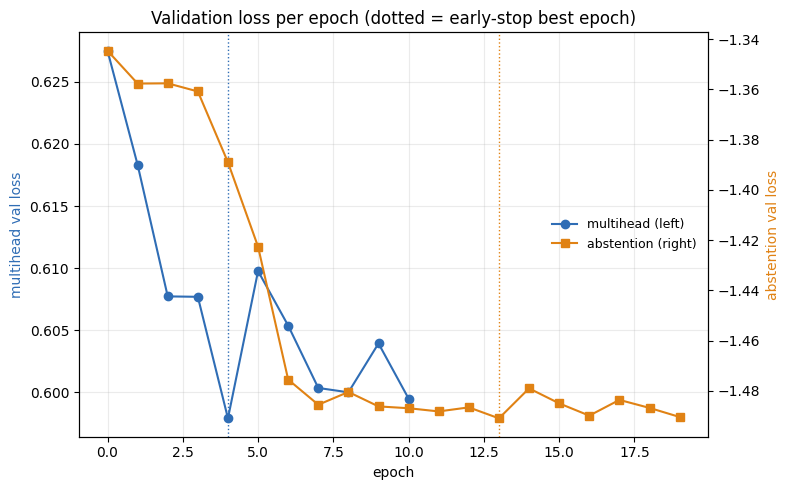

In [58]:
# Per-epoch validation loss for both losses (different scales -> twin axes).
# The histories ride along in each checkpoint (saved by run_cli), so this needs
# no retraining -- but checkpoints trained before that field was added show empty.
fig, ax = plt.subplots(figsize=(8, 5))
h_mh, h_ab = enc_mh["val_loss_history"], enc_ab["val_loss_history"]
ax.plot(range(len(h_mh)), h_mh, "o-", color="#2f6db5", label="multihead (left)")
ax.axvline(enc_mh["best_epoch"], color="#2f6db5", ls=":", lw=1)
ax2 = ax.twinx()
ax2.plot(range(len(h_ab)), h_ab, "s-", color="#e08214", label="abstention (right)")
ax2.axvline(enc_ab["best_epoch"], color="#e08214", ls=":", lw=1)
ax.set_xlabel("epoch")
ax.set_ylabel("multihead val loss", color="#2f6db5")
ax2.set_ylabel("abstention val loss", color="#e08214")
ax.set_title("Validation loss per epoch (dotted = early-stop best epoch)")
ax.grid(alpha=0.25)
# combined legend from both axes, placed clear of the title
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc="center right")
fig.tight_layout()
fig.savefig(figs / "training_curves.png", dpi=140)
plt.show()

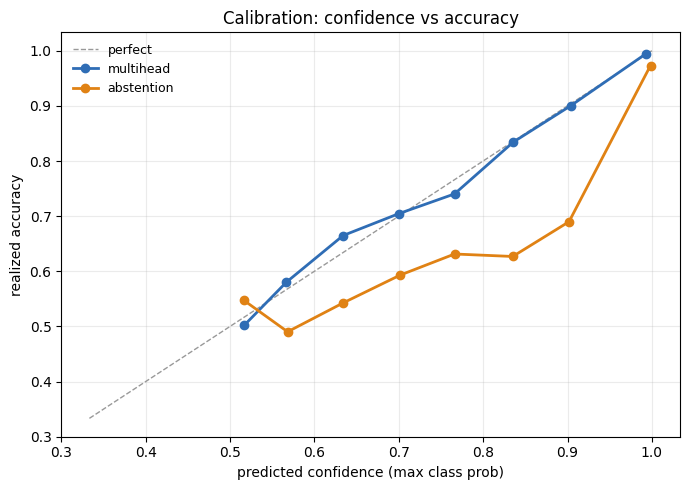

In [59]:
# Calibration / reliability diagram: predicted confidence vs realized accuracy.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([1 / 3, 1], [1 / 3, 1], color="#999", ls="--", lw=1, label="perfect")
for pack, color, label in [(mh, "#2f6db5", "multihead"), (ab, "#e08214", "abstention")]:
    # abstention real-class probs do not sum to 1 -> renormalize for confidence
    p = pack["defect_prob"]
    p = p / p.sum(1, keepdims=True)
    conf = p.max(1)
    correct = (pack["d_pred"] == pack["y"]).astype(float)
    bins = np.linspace(1 / 3, 1.0, 11)
    idx = np.clip(np.digitize(conf, bins) - 1, 0, len(bins) - 2)
    xs, ys = [], []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.sum() < 20:
            continue
        xs.append(conf[m].mean()); ys.append(correct[m].mean())
    ax.plot(xs, ys, "o-", color=color, lw=2, label=label)
ax.set_xlabel("predicted confidence (max class prob)")
ax.set_ylabel("realized accuracy")
ax.set_title("Calibration: confidence vs accuracy")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(figs / "calibration.png", dpi=140)
plt.show()

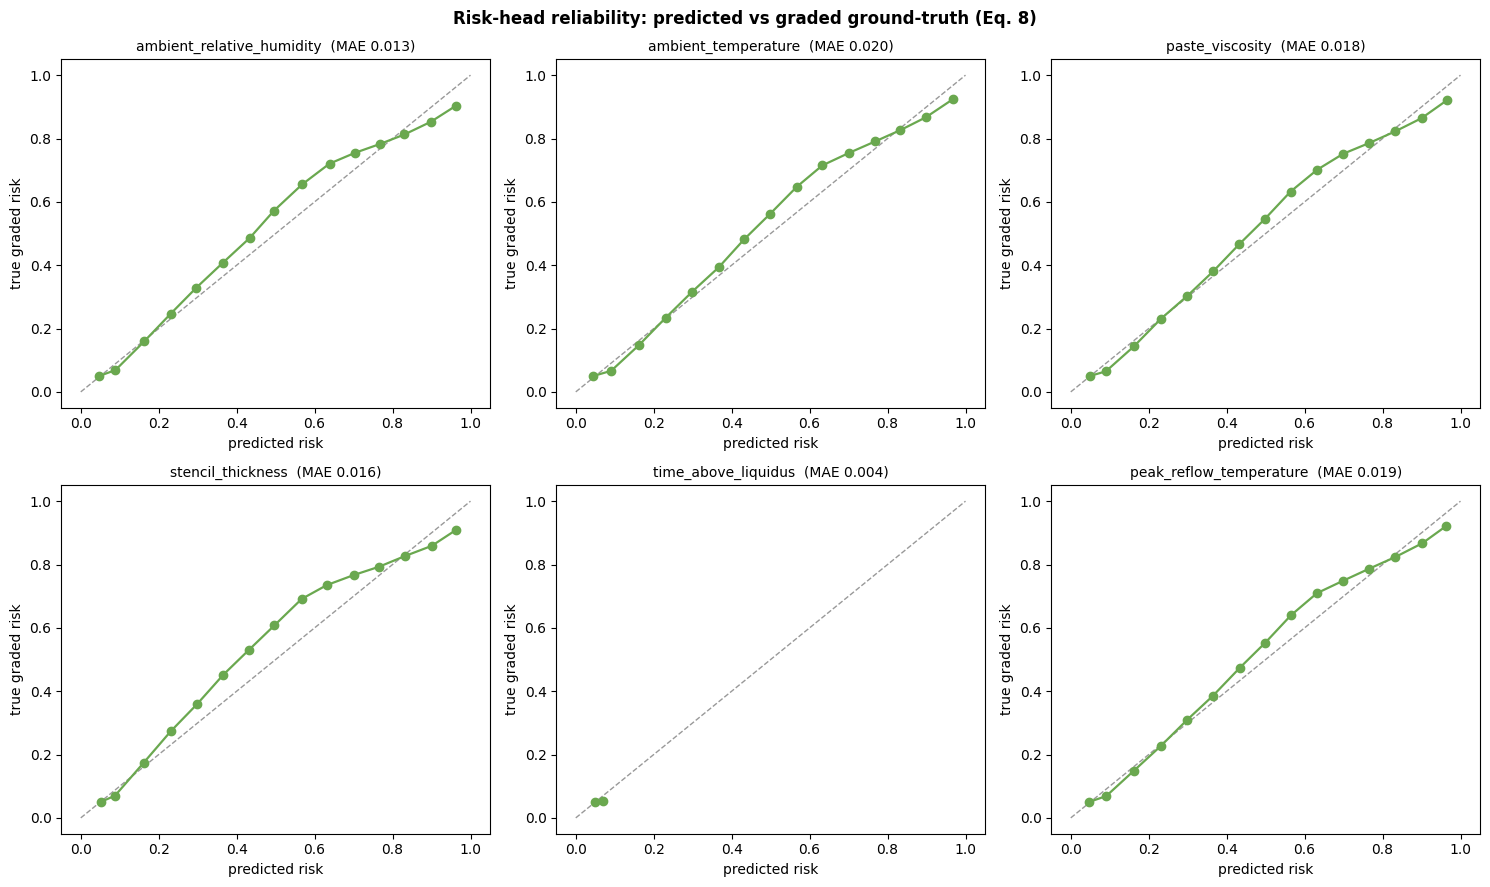

In [60]:
# Risk-head reliability: predicted parameter risk vs the graded ground-truth (Eq. 8).
ids = param_ids(spec)
pred, true = mh["risk_prob"], mh["y_risk"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, pid, j in zip(axes.ravel(), ids, range(len(ids))):
    p, t = pred[:, j], true[:, j]
    # bin predictions, plot mean true target per bin against the diagonal
    bins = np.linspace(0, 1, 16)
    idx = np.clip(np.digitize(p, bins) - 1, 0, len(bins) - 2)
    xs, ys = [], []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.any():
            xs.append(p[m].mean()); ys.append(t[m].mean())
    ax.plot([0, 1], [0, 1], color="#999", ls="--", lw=1)
    ax.plot(xs, ys, "o-", color="#6aa84f", lw=1.6)
    ax.set_title(f"{pid}  (MAE {np.abs(p - t).mean():.3f})", fontsize=10)
    ax.set_xlabel("predicted risk"); ax.set_ylabel("true graded risk")
fig.suptitle("Risk-head reliability: predicted vs graded ground-truth (Eq. 8)", fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "risk_reliability.png", dpi=140)
plt.show()

## Abstention analysis (the prof's three questions)

Do we reject? What's the train/test gap? Who gets flagged? All from the loaded abstention model.

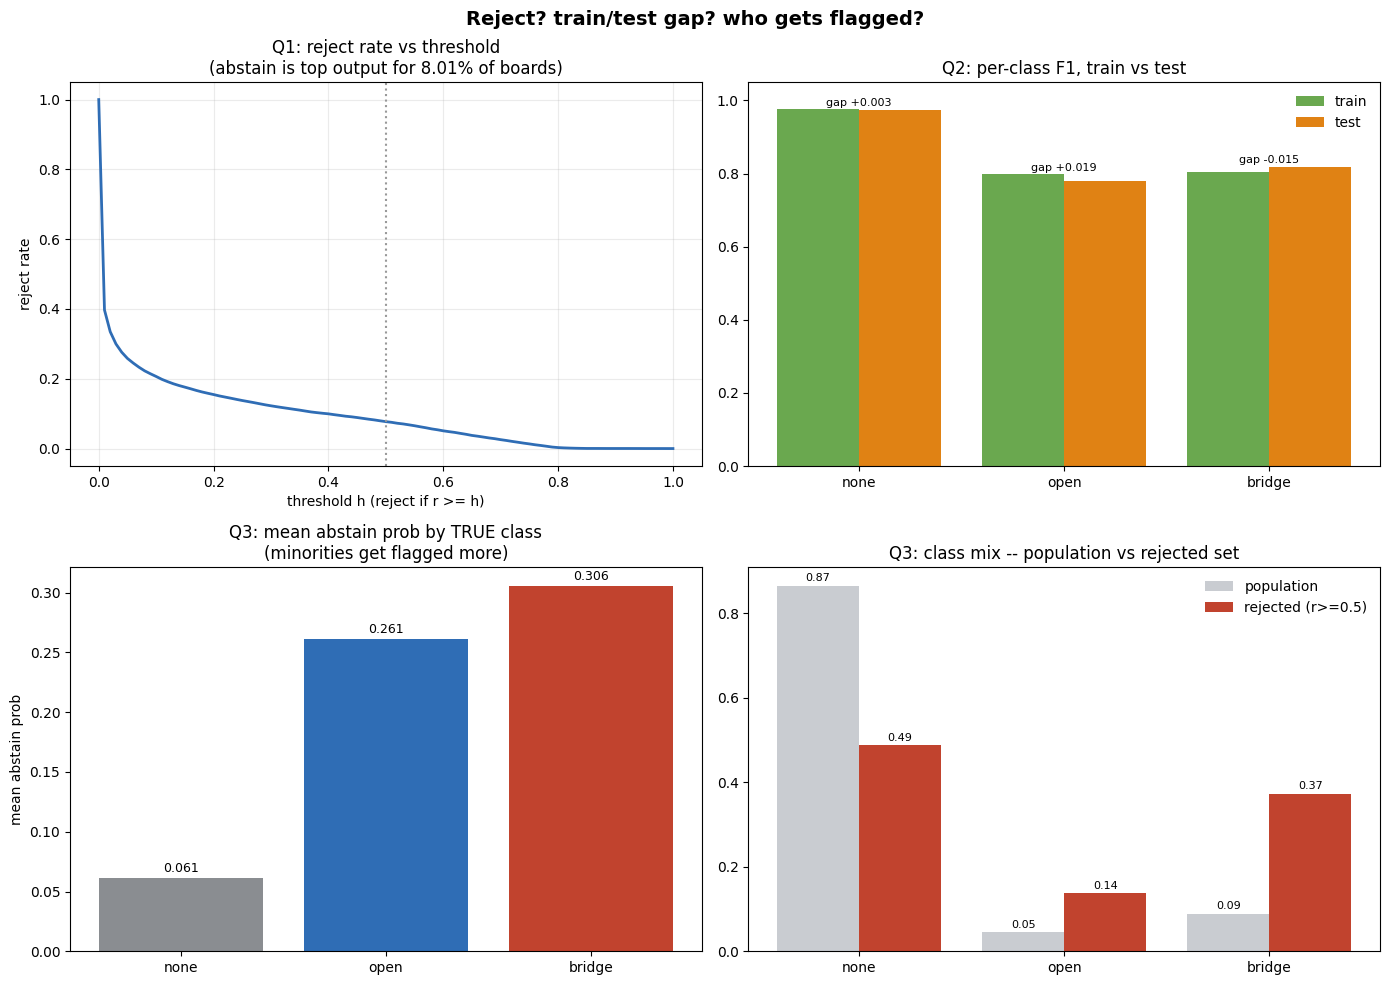

In [61]:
# The prof's three questions, all from the loaded abstention model (no retraining):
#   Q1 do we reject?   Q2 train-vs-test per-class F1?   Q3 who gets flagged?
ab_te = ab                                          # test pack (already loaded)
ab_tr = _pack(model_ab, enc_ab, df, spec, split="train")
y, rr = ab_te["y"], ab_te["r"]
SHORT3 = ["none", "open", "bridge"]
COL3 = ["#8a8d91", "#2f6db5", "#c1432e"]


def per_class_f1(yt, yp):
    """Per-class F1 over the 3 defect classes."""
    _, _, f, _ = precision_recall_fscore_support(yt, yp, labels=[0, 1, 2], zero_division=0)
    return f


# Q1: reject rate vs threshold; how often abstain wins the m+1-way argmax
reject_argmax = float((rr > ab_te["defect_prob"].max(1)).mean())
ths = np.linspace(0, 1, 101)
reject_rate = [float((rr >= h).mean()) for h in ths]

# Q2: per-class F1 train vs test (gap = train - test)
f1_tr = per_class_f1(ab_tr["y"], ab_tr["d_pred"])
f1_te = per_class_f1(y, ab_te["d_pred"])

# Q3: abstain prob by TRUE class + class mix of the rejected set (r >= 0.5)
means = [float(rr[y == c].mean()) for c in range(3)]
rej = rr >= 0.5
pop_mix = [float((y == c).mean()) for c in range(3)]
rej_mix = [float((y[rej] == c).mean()) if rej.any() else 0.0 for c in range(3)]

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(3)

# (1) reject rate vs threshold
ax[0, 0].plot(ths, reject_rate, color="#2f6db5", lw=2)
ax[0, 0].axvline(0.5, color="#999", ls=":")
ax[0, 0].set_title(f"Q1: reject rate vs threshold\n(abstain is top output for {reject_argmax*100:.2f}% of boards)")
ax[0, 0].set_xlabel("threshold h (reject if r >= h)")
ax[0, 0].set_ylabel("reject rate")
ax[0, 0].grid(alpha=0.25)

# (2) per-class F1 train vs test
ax[0, 1].bar(x - 0.2, f1_tr, 0.4, label="train", color="#6aa84f")
ax[0, 1].bar(x + 0.2, f1_te, 0.4, label="test", color="#e08214")
for i in range(3):
    ax[0, 1].text(i, max(f1_tr[i], f1_te[i]) + 0.01, f"gap {f1_tr[i]-f1_te[i]:+.3f}",
                  ha="center", fontsize=8)
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(SHORT3); ax[0, 1].set_ylim(0, 1.05)
ax[0, 1].set_title("Q2: per-class F1, train vs test")
ax[0, 1].legend(frameon=False)

# (3) mean abstain prob by TRUE class
ax[1, 0].bar(x, means, color=COL3)
for i, v in enumerate(means):
    ax[1, 0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels(SHORT3)
ax[1, 0].set_title("Q3: mean abstain prob by TRUE class\n(minorities get flagged more)")
ax[1, 0].set_ylabel("mean abstain prob")

# (4) class mix: population vs rejected set
ax[1, 1].bar(x - 0.2, pop_mix, 0.4, label="population", color="#c9ccd1")
ax[1, 1].bar(x + 0.2, rej_mix, 0.4, label="rejected (r>=0.5)", color="#c1432e")
for i in range(3):
    ax[1, 1].text(i - 0.2, pop_mix[i] + 0.01, f"{pop_mix[i]:.2f}", ha="center", fontsize=8)
    ax[1, 1].text(i + 0.2, rej_mix[i] + 0.01, f"{rej_mix[i]:.2f}", ha="center", fontsize=8)
ax[1, 1].set_xticks(x); ax[1, 1].set_xticklabels(SHORT3)
ax[1, 1].set_title("Q3: class mix -- population vs rejected set")
ax[1, 1].legend(frameon=False)

fig.suptitle("Reject? train/test gap? who gets flagged?", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "prof_questions.png", dpi=140)
plt.show()

## Data characterization (no model)

Distribution and separability plots straight from the dataset — these don't use the trained models. (The two `bayes_summary` / `defect_metrics` figures stay in `analysis.py` because they retrain a small sklearn MLP inline.)

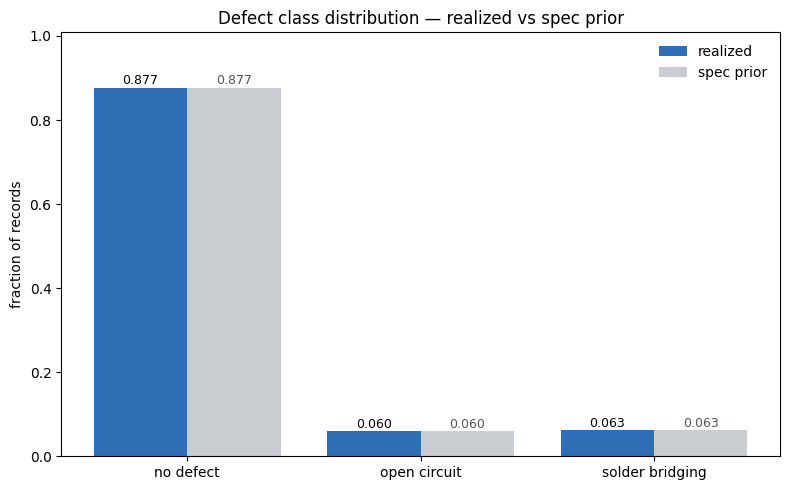

In [62]:
# Defect class distribution: realized fraction vs the spec prior.
names = defect_names(spec)
counts = df["defect_label"].value_counts().reindex(names).fillna(0).astype(int)
fracs = counts / counts.sum()
priors = {d["name"]: d["prior"] for d in spec["defects"]}

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(names))
ax.bar(x - 0.2, fracs.values, width=0.4, label="realized", color="#2f6db5")
ax.bar(x + 0.2, [priors[n] for n in names], width=0.4, label="spec prior", color="#c9ccd1")
for i, n in enumerate(names):
    ax.text(i - 0.2, fracs[n] + 0.008, f"{fracs[n]:.3f}", ha="center", fontsize=9)
    ax.text(i + 0.2, priors[n] + 0.008, f"{priors[n]:.3f}", ha="center", fontsize=9, color="#555")
ax.set_xticks(x)
ax.set_xticklabels([n.replace("_", " ") for n in names])
ax.set_ylabel("fraction of records")
ax.set_ylim(0, max(fracs.max(), max(priors.values())) * 1.15)
ax.set_title("Defect class distribution — realized vs spec prior")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(figs / "class_balance.png", dpi=140)
plt.show()

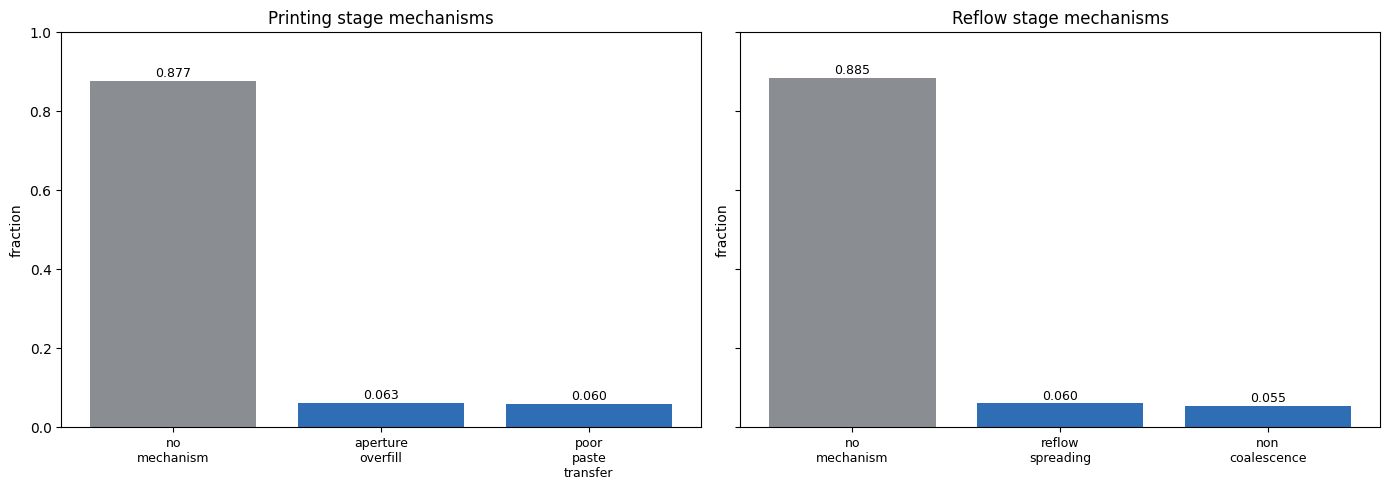

In [63]:
# Per-stage mechanism-label distribution.
stages = list(spec["mechanisms"].keys())
fig, axes = plt.subplots(1, len(stages), figsize=(7 * len(stages), 5), sharey=True)
for ax, stage in zip(np.atleast_1d(axes), stages):
    # fraction of each mechanism in this stage
    order = spec["mechanisms"][stage]
    fr = df[f"{stage}_mechanism_label"].value_counts(normalize=True).reindex(order).fillna(0)

    # grey for no_mechanism, blue for the real ones
    colors = ["#8a8d91"] + ["#2f6db5"] * (len(order) - 1)
    bars = ax.bar(range(len(order)), fr.values, color=colors)
    for b, v in zip(bars, fr.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}",
                ha="center", fontsize=9)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([m.replace("_", "\n") for m in order], fontsize=9)
    ax.set_title(stage.replace("stage_", "").capitalize() + " stage mechanisms")
    ax.set_ylabel("fraction")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(figs / "mechanism_balance.png", dpi=140)
plt.show()

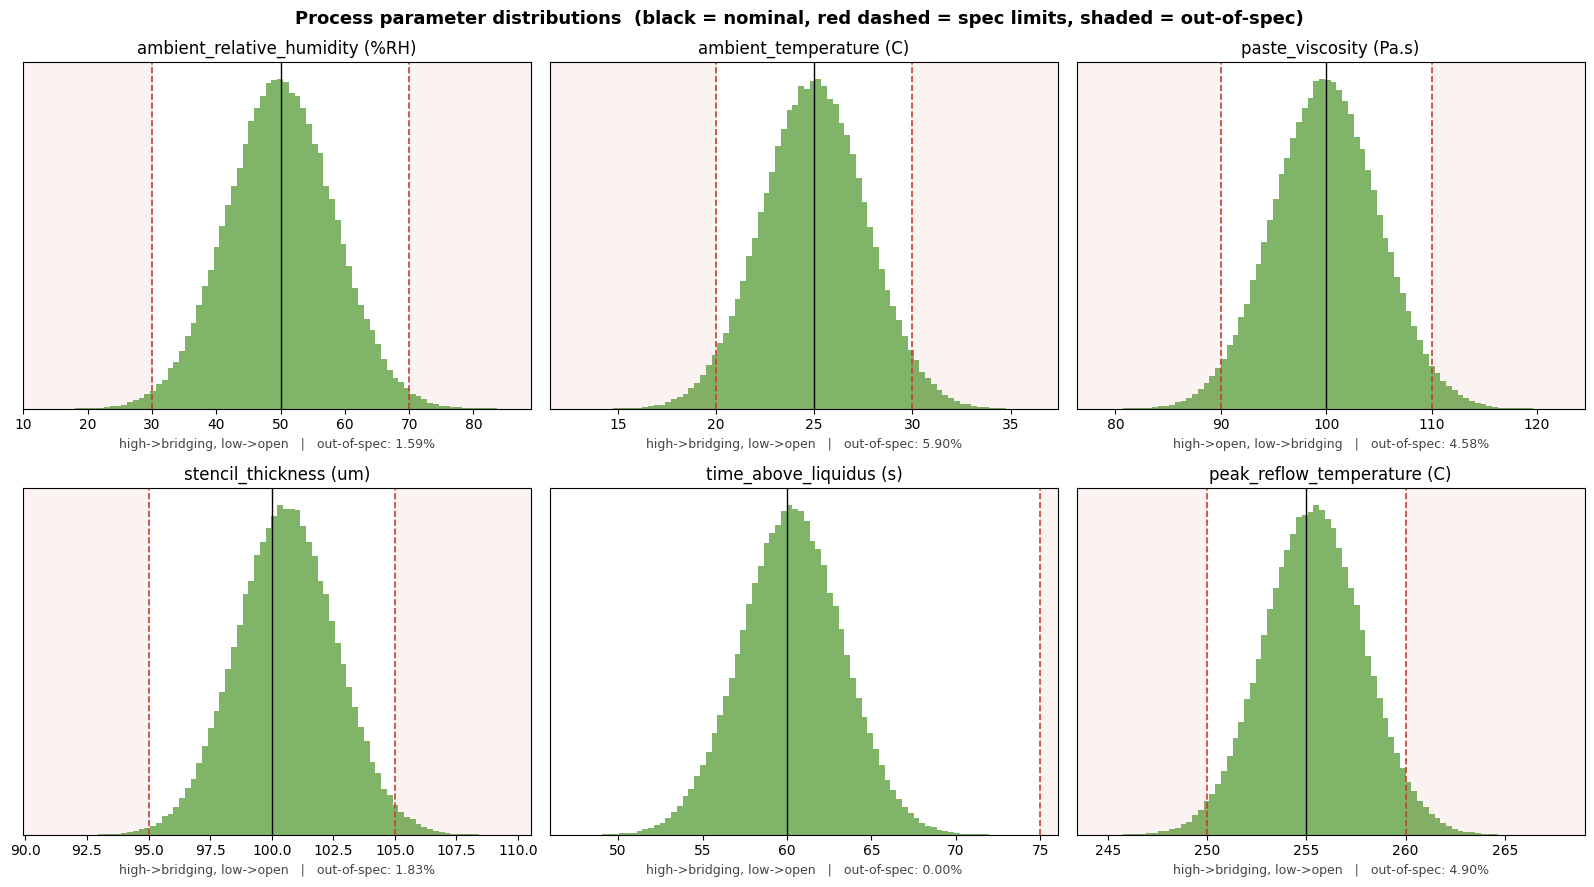

In [64]:
# Per-parameter value histograms with spec limits + out-of-spec rate.
SPEC_RED = "#c1432e"
notes = param_causal_note(spec)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, p in zip(axes.ravel(), spec["parameters"]):
    vals = df[p["id"]]

    # share of records outside the spec window
    oos = float(((vals < p["lsl"]) | (vals > p["usl"])).mean())
    ax.hist(vals, bins=80, color="#6aa84f", alpha=0.85)

    # shade the out-of-spec regions and mark nominal + limits
    lo, hi = ax.get_xlim()
    ax.axvspan(lo, p["lsl"], color=SPEC_RED, alpha=0.06)
    ax.axvspan(p["usl"], hi, color=SPEC_RED, alpha=0.06)
    ax.set_xlim(lo, hi)
    ax.axvline(p["nominal"], color="k", linewidth=1)
    for b in ("lsl", "usl"):
        ax.axvline(p[b], color=SPEC_RED, linestyle="--", linewidth=1.2)
    ax.set_title(f"{p['id']} ({p['unit']})")
    ax.set_xlabel(f"{notes[p['id']]}   |   out-of-spec: {oos*100:.2f}%",
                  fontsize=9, color="#444")
    ax.set_yticks([])
fig.suptitle("Process parameter distributions  (black = nominal, red dashed = spec limits, shaded = out-of-spec)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "parameter_hists.png", dpi=140)
plt.show()

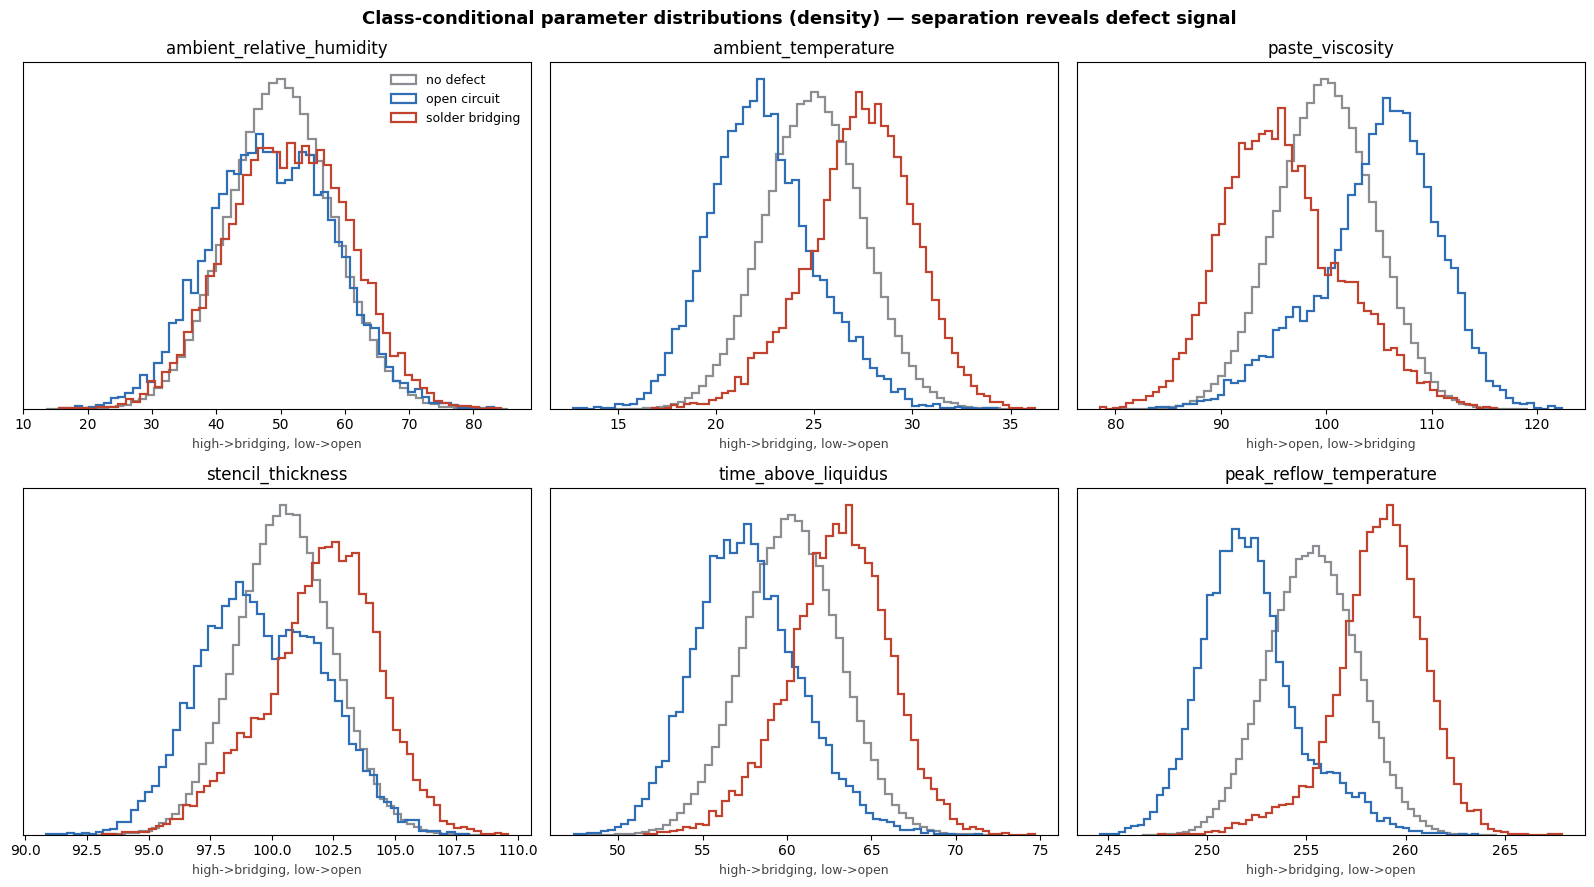

In [65]:
# Class-conditional parameter distributions: which parameters carry defect signal.
names = defect_names(spec)
notes = param_causal_note(spec)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, p in zip(axes.ravel(), spec["parameters"]):
    # one outline density per class
    for n in names:
        sub = df.loc[df["defect_label"] == n, p["id"]]
        ax.hist(sub, bins=60, density=True, histtype="step", linewidth=1.6,
                color=DEFECT_HEX.get(n), label=n.replace("_", " "))

    # grey out the title for nuisance parameters
    nuisance = "nuisance" in notes[p["id"]]
    ax.set_title(p["id"] + ("  [nuisance]" if nuisance else ""),
                 color="#999" if nuisance else "black")
    ax.set_xlabel(notes[p["id"]], fontsize=9, color="#444")
    ax.set_yticks([])
axes.ravel()[0].legend(frameon=False, fontsize=9)
fig.suptitle("Class-conditional parameter distributions (density) — separation reveals defect signal",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "class_conditional.png", dpi=140)
plt.show()

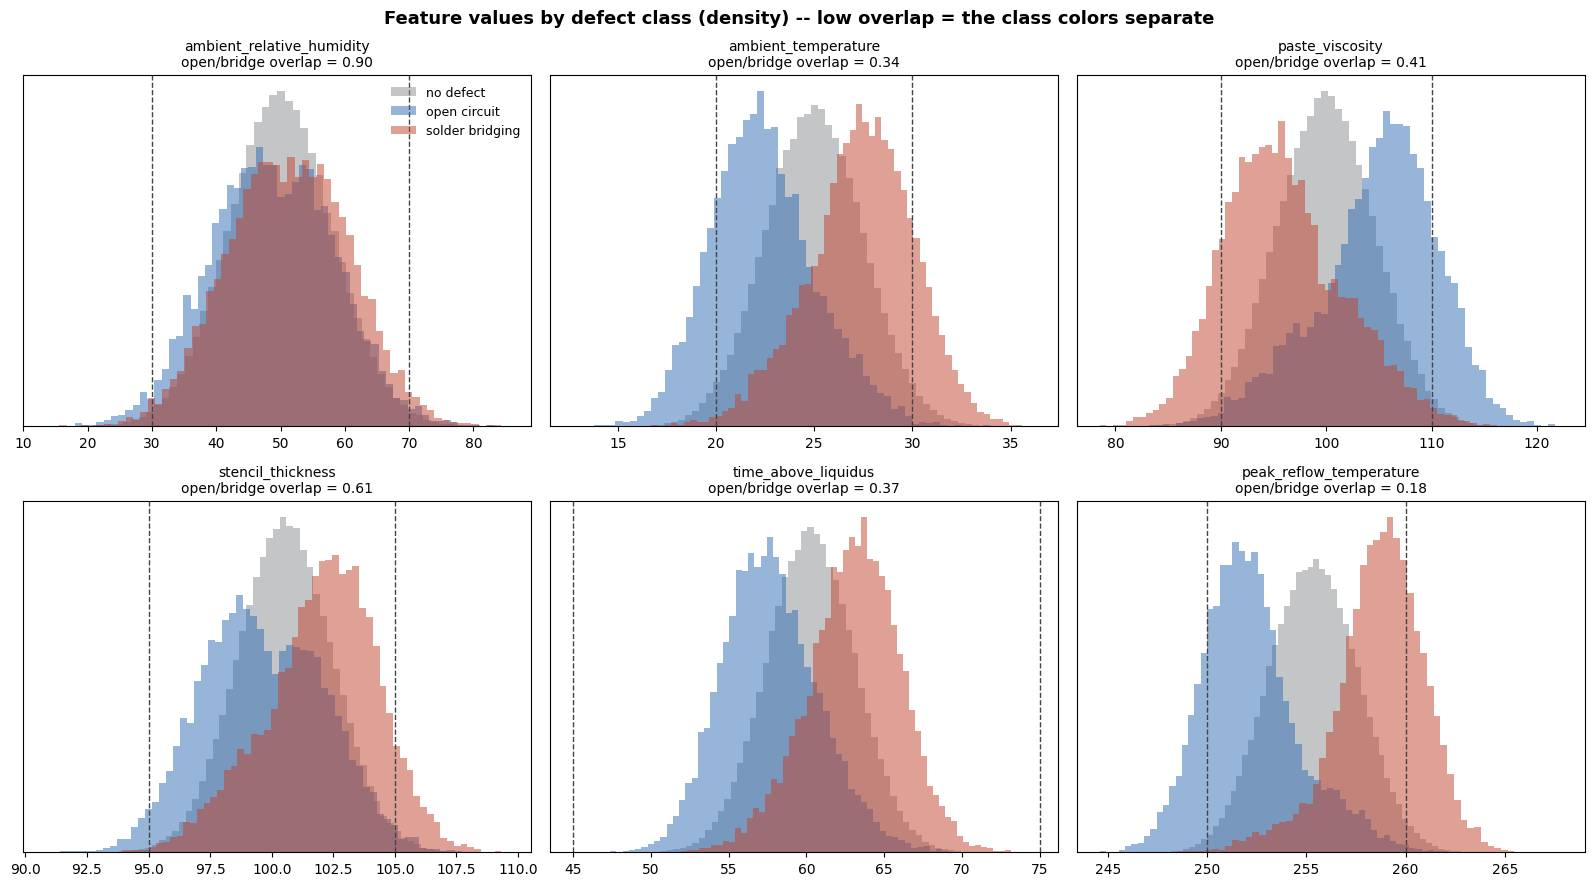

open-vs-bridge overlap per feature (lower = colors separate more):
  peak_reflow_temperature      0.182
  ambient_temperature          0.345
  time_above_liquidus          0.366
  paste_viscosity              0.414
  stencil_thickness            0.610
  ambient_relative_humidity    0.897


In [66]:
# Separability sanity check: per-feature class histograms + open/bridge overlap.
# The prof's hypothesis: at least one feature where the class colors barely overlap.
names = defect_names(spec)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scores = {}
for ax, p in zip(axes.ravel(), spec["parameters"]):
    # split this feature's values by defect class
    vals = {n: df.loc[df["defect_label"] == n, p["id"]].to_numpy() for n in names}

    # one filled, translucent density histogram per class (so hues overlap visibly)
    for n in names:
        ax.hist(vals[n], bins=60, density=True, alpha=0.5, color=DEFECT_HEX[n],
                label=n.replace("_", " "))
    for b in ("lsl", "usl"):
        ax.axvline(p[b], color="#444", linestyle="--", linewidth=1)

    # headline overlap = the two oppositely-shifted classes (open vs bridging)
    ovl = overlap(vals["open_circuit"], vals["solder_bridging"])
    scores[p["id"]] = ovl
    ax.set_title(f"{p['id']}\nopen/bridge overlap = {ovl:.2f}", fontsize=10)
    ax.set_yticks([])
axes.ravel()[0].legend(frameon=False, fontsize=9)
fig.suptitle("Feature values by defect class (density) -- low overlap = the class colors separate",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(figs / "feature_separability.png", dpi=140)
plt.show()

print("open-vs-bridge overlap per feature (lower = colors separate more):")
for pid, v in sorted(scores.items(), key=lambda kv: kv[1]):
    print(f"  {pid:28s} {v:.3f}")

## Learning curve

How test performance scales with training-set size (read from `results/learning_curve.json`).

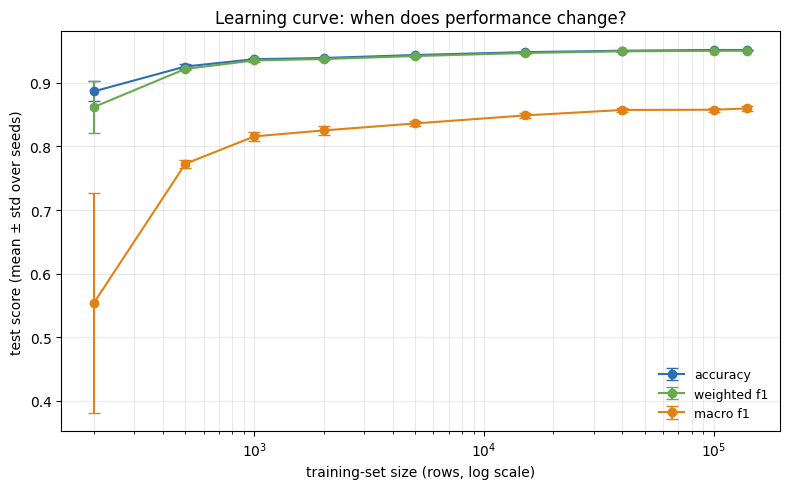

In [67]:
# Learning curve: test score vs training-set size, read from the precomputed JSON.
# learning_curve.py retrains many subset models, so run it once on the CLI and
# just plot its result here:  python learning_curve.py
lc = json.load(open("results/learning_curve.json"))
sizes = sorted(int(k) for k in lc)
metrics_lc = ["accuracy", "weighted_f1", "macro_f1"]
colors = {"accuracy": "#2f6db5", "weighted_f1": "#6aa84f", "macro_f1": "#e08214"}

fig, ax = plt.subplots(figsize=(8, 5))
for mname in metrics_lc:
    means = [lc[str(n)][mname]["mean"] for n in sizes]
    stds = [lc[str(n)][mname]["std"] for n in sizes]
    ax.errorbar(sizes, means, yerr=stds, marker="o", capsize=4,
                color=colors[mname], label=mname.replace("_", " "))
ax.set_xscale("log")
ax.set_xlabel("training-set size (rows, log scale)")
ax.set_ylabel("test score (mean ± std over seeds)")
ax.set_title("Learning curve: when does performance change?")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
fig.savefig(figs / "learning_curve.png", dpi=140)
plt.show()